In [1]:
import pandas as pd
import numpy as np
import operator 
import re
import gc
import keras
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')
import math



from keras.models import Sequential
from keras.layers import CuDNNLSTM, Dense, Bidirectional, Dropout
from keras.callbacks import Callback
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

Using TensorFlow backend.


## Loading data

In [2]:
train = pd.read_csv("../input/train.csv")
test = pd.read_csv("../input/test.csv")
df = pd.concat([train ,test])

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:3: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  This is separate from the ipykernel package so we can avoid doing imports until


In [3]:
print("Number of texts: ", df.shape[0])

Number of texts:  1681928


## Loading embeddings
#### In this v2, I am using GloVe only, for memory usage purposes mostly.

In [4]:
def load_embed(file):
    def get_coefs(word,*arr): 
        return word, np.asarray(arr, dtype='float32')
    
    if file == '../input/embeddings/wiki-news-300d-1M/wiki-news-300d-1M.vec':
        embeddings_index = dict(get_coefs(*o.split(" ")) for o in open(file) if len(o)>100)
    else:
        embeddings_index = dict(get_coefs(*o.split(" ")) for o in open(file, encoding='latin'))
        
    return embeddings_index

In [5]:
glove = '../input/embeddings/glove.840B.300d/glove.840B.300d.txt'

In [6]:
print("Extracting GloVe embedding")
embed_glove = load_embed(glove)

Extracting GloVe embedding


## Vocabulary and Coverage functions
> Again, check Dieter's work if you haven't, those are his.

In [7]:
def build_vocab(texts):
    sentences = texts.apply(lambda x: x.split()).values
    vocab = {}
    for sentence in sentences:
        for word in sentence:
            try:
                vocab[word] += 1
            except KeyError:
                vocab[word] = 1
    return vocab

In [8]:
def check_coverage(vocab, embeddings_index):
    known_words = {}
    unknown_words = {}
    nb_known_words = 0
    nb_unknown_words = 0
    for word in vocab.keys():
        try:
            known_words[word] = embeddings_index[word]
            nb_known_words += vocab[word]
        except:
            unknown_words[word] = vocab[word]
            nb_unknown_words += vocab[word]
            pass

    print('Found embeddings for {:.3%} of vocab'.format(len(known_words) / len(vocab)))
    print('Found embeddings for  {:.3%} of all text'.format(nb_known_words / (nb_known_words + nb_unknown_words)))
    unknown_words = sorted(unknown_words.items(), key=operator.itemgetter(1))[::-1]

    return unknown_words

## Starting point

In [9]:
vocab = build_vocab(df['question_text'])

In [10]:
print("Glove : ")
oov_glove = check_coverage(vocab, embed_glove)

Glove : 
Found embeddings for 31.537% of vocab
Found embeddings for  88.155% of all text


#### Apply lowerization (necessary if using paragram)
> Fasttext and GloVe understand capitalization, but you still win a bit.

In [11]:
df['lowered_question'] = df['question_text'].apply(lambda x: x.lower())

#### If you apply lowerization, you lost a bit of informations on other embeddings :
> Therer are words known that are known with upper letters and unknown without. Let us fix that :
- word.lower() takes the embedding of word if word.lower() doesn't have an embedding

In [12]:
def add_lower(embedding, vocab):
    count = 0
    for word in vocab:
        if word in embedding and word.lower() not in embedding:  
            embedding[word.lower()] = embedding[word]
            count += 1
    print(f"Added {count} words to embedding")

In [13]:
print("Glove : ")
oov_glove = check_coverage(vocab, embed_glove)
add_lower(embed_glove, vocab)
oov_glove = check_coverage(vocab, embed_glove)

Glove : 
Found embeddings for 31.537% of vocab
Found embeddings for  88.155% of all text
Added 17744 words to embedding
Found embeddings for 31.820% of vocab
Found embeddings for  88.171% of all text


### What's wrong ?

In [14]:
oov_glove[:10]

[('India?', 21063),
 ('it?', 16623),
 ("What's", 16104),
 ('do?', 11211),
 ('life?', 9993),
 ('you?', 8083),
 ('me?', 7982),
 ('them?', 7910),
 ('time?', 7379),
 ('world?', 6941)]

#### First faults appearing are : 
- Contractions 
- Words with punctuation in them

> Let us correct that.

## Contractions

In [15]:
contraction_mapping = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",  "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",  "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have" }

In [16]:
def known_contractions(embed):
    known = []
    for contract in contraction_mapping:
        if contract in embed:
            known.append(contract)
    return known

In [17]:
print("- Known Contractions -")
print("   Glove :")
print(known_contractions(embed_glove))

- Known Contractions -
   Glove :
["can't", "'cause", "didn't", "doesn't", "don't", "I'd", "I'll", "I'm", "I've", "i'd", "i'll", "i'm", "i've", "it's", "ma'am", "o'clock", "that's", "you'll", "you're"]


#### Not a lot of contractions are known. (FastText knows none)
> We use the map to replace them

In [18]:
def clean_contractions(text, mapping):
    specials = ["’", "‘", "´", "`"]
    for s in specials:
        text = text.replace(s, "'")
    text = ' '.join([mapping[t] if t in mapping else t for t in text.split(" ")])
    return text

In [19]:
df['treated_question'] = df['lowered_question'].apply(lambda x: clean_contractions(x, contraction_mapping))

In [20]:
vocab = build_vocab(df['treated_question'])
print("Glove : ")
oov_glove = check_coverage(vocab, embed_glove)

Glove : 
Found embeddings for 29.302% of vocab
Found embeddings for  88.570% of all text


## Now, let us deal with special characters

In [21]:
punct = "/-'?!.,#$%\'()*+-/:;<=>@[\\]^_`{|}~" + '""“”’' + '∞θ÷α•à−β∅³π‘₹´°£€\×™√²—–&'

In [22]:
def unknown_punct(embed, punct):
    unknown = ''
    for p in punct:
        if p not in embed:
            unknown += p
            unknown += ' '
    return unknown

In [23]:
print("Glove :")
print(unknown_punct(embed_glove, punct))

Glove :
“ ” ’ ∞ θ ÷ α • à − β ∅ ³ π ‘ ₹ ´ ° £ € × ™ √ ² — – 


#### Some characters are unknown.
> We use a map to replace unknown characters with known ones.

> We make sure there are spaces between words and punctuation


In [24]:
punct_mapping = {"‘": "'", "₹": "e", "´": "'", "°": "", "€": "e", "™": "tm", "√": " sqrt ", "×": "x", "²": "2", "—": "-", "–": "-", "’": "'", "_": "-", "`": "'", '“': '"', '”': '"', '“': '"', "£": "e", '∞': 'infinity', 'θ': 'theta', '÷': '/', 'α': 'alpha', '•': '.', 'à': 'a', '−': '-', 'β': 'beta', '∅': '', '³': '3', 'π': 'pi', }

In [25]:
def clean_special_chars(text, punct, mapping):
    for p in mapping:
        text = text.replace(p, mapping[p])
    
    for p in punct:
        text = text.replace(p, f' {p} ')
    
    specials = {'\u200b': ' ', '…': ' ... ', '\ufeff': '', 'करना': '', 'है': ''}  # Other special characters that I have to deal with in last
    for s in specials:
        text = text.replace(s, specials[s])
    
    return text

In [26]:
df['treated_question'] = df['treated_question'].apply(lambda x: clean_special_chars(x, punct, punct_mapping))

In [27]:
vocab = build_vocab(df['treated_question'])
print("Glove : ")
oov_glove = check_coverage(vocab, embed_glove)

Glove : 
Found embeddings for 66.961% of vocab
Found embeddings for  99.580% of all text


In [28]:
oov_glove[:100]

[('quorans', 1064),
 ('brexit', 682),
 ('cryptocurrencies', 626),
 ('redmi', 488),
 ('oneplus', 177),
 ('coinbase', 176),
 ('uceed', 152),
 ('demonetisation', 148),
 ('bhakts', 145),
 ('upwork', 142),
 ('pokémon', 142),
 ('machedo', 141),
 ('boruto', 136),
 ('adityanath', 132),
 ('gdpr', 130),
 ('bnbr', 126),
 ('alshamsi', 123),
 ('sjws', 116),
 ('iiest', 115),
 ('unacademy', 113),
 ('litecoin', 110),
 ('dceu', 109),
 ('tensorflow', 104),
 ('zerodha', 100),
 ('qoura', 98),
 ('lnmiit', 91),
 ('fiancé', 90),
 ('nicmar', 89),
 ('kavalireddi', 86),
 ('muoet', 85),
 ('doklam', 81),
 ('vajiram', 80),
 ('elitmus', 73),
 ('altcoin', 72),
 ('altcoins', 72),
 ('jiren', 71),
 ('awdhesh', 71),
 ('adhaar', 70),
 ('hackerrank', 68),
 ('srmjee', 68),
 ('zebpay', 68),
 ('baahubali', 63),
 ('koinex', 60),
 ('mhcet', 58),
 ('byju', 58),
 ('binance', 58),
 ('ryzen', 58),
 ('beerus', 54),
 ('chromecast', 50),
 ('srmjeee', 50),
 ('gurugram', 50),
 ('ftre', 49),
 ('skripal', 49),
 ('bmsce', 48),
 ('nanodegr

### What's still missing ? 
- Unknown words
- Acronyms
- Spelling mistakes

## We can correct manually most frequent mispells

#### For example, here are some mistakes and their frequency
- qoura : 85 times
- mastrubation : 38 times
- demonitisation : 30 times
- …

In [29]:
mispell_dict = {'colour': 'color', 'centre': 'center', 'favourite': 'favorite', 'travelling': 'traveling', 'counselling': 'counseling', 'theatre': 'theater', 'cancelled': 'canceled', 'labour': 'labor', 'organisation': 'organization', 'wwii': 'world war 2', 'citicise': 'criticize', 'youtu ': 'youtube ', 'Qoura': 'Quora', 'sallary': 'salary', 'Whta': 'What', 'narcisist': 'narcissist', 'howdo': 'how do', 'whatare': 'what are', 'howcan': 'how can', 'howmuch': 'how much', 'howmany': 'how many', 'whydo': 'why do', 'doI': 'do I', 'theBest': 'the best', 'howdoes': 'how does', 'mastrubation': 'masturbation', 'mastrubate': 'masturbate', "mastrubating": 'masturbating', 'pennis': 'penis', 'Etherium': 'Ethereum', 'narcissit': 'narcissist', 'bigdata': 'big data', '2k17': '2017', '2k18': '2018', 'qouta': 'quota', 'exboyfriend': 'ex boyfriend', 'airhostess': 'air hostess', "whst": 'what', 'watsapp': 'whatsapp', 'demonitisation': 'demonetization', 'demonitization': 'demonetization', 'demonetisation': 'demonetization', 'pokémon': 'pokemon'}

In [30]:
def correct_spelling(x, dic):
    for word in dic.keys():
        x = x.replace(word, dic[word])
    return x

In [31]:
df['treated_question'] = df['treated_question'].apply(lambda x: correct_spelling(x, mispell_dict))

In [32]:
vocab = build_vocab(df['treated_question'])
print("Glove : ")
oov_glove = check_coverage(vocab, embed_glove)

Glove : 
Found embeddings for 66.958% of vocab
Found embeddings for  99.582% of all text


In [33]:
len(vocab)

224215

In [34]:
vocab['and']

332231

In [35]:
vocab_filter={}
for i in vocab.keys():
    if vocab[i]>20:
        vocab_filter[i]=vocab[i]

In [36]:
len(vocab_filter)

26497

In [37]:
del oov_glove, df, vocab, vocab_filter
gc.collect()

7

In [38]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1306122 entries, 0 to 1306121
Data columns (total 3 columns):
qid              1306122 non-null object
question_text    1306122 non-null object
target           1306122 non-null int64
dtypes: int64(1), object(2)
memory usage: 29.9+ MB


In [39]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375806 entries, 0 to 375805
Data columns (total 2 columns):
qid              375806 non-null object
question_text    375806 non-null object
dtypes: object(2)
memory usage: 5.7+ MB


# Part 2 : Checking the improvement

## Applying treatment

I only treat train data here, because I do not intend to submit my results.

In [40]:
# Lowering
train['treated_question'] = train['question_text'].apply(lambda x: x.lower())
# Contractions
train['treated_question'] = train['treated_question'].apply(lambda x: clean_contractions(x, contraction_mapping))
# Special characters
train['treated_question'] = train['treated_question'].apply(lambda x: clean_special_chars(x, punct, punct_mapping))
# Spelling mistakes
train['treated_question'] = train['treated_question'].apply(lambda x: correct_spelling(x, mispell_dict))

In [41]:
# Lowering
test['treated_question'] = test['question_text'].apply(lambda x: x.lower())
# Contractions
test['treated_question'] = test['treated_question'].apply(lambda x: clean_contractions(x, contraction_mapping))
# Special characters
test['treated_question'] = test['treated_question'].apply(lambda x: clean_special_chars(x, punct, punct_mapping))
# Spelling mistakes
test['treated_question'] = test['treated_question'].apply(lambda x: correct_spelling(x, mispell_dict))

In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1306122 entries, 0 to 1306121
Data columns (total 4 columns):
qid                 1306122 non-null object
question_text       1306122 non-null object
target              1306122 non-null int64
treated_question    1306122 non-null object
dtypes: int64(1), object(3)
memory usage: 39.9+ MB


## Data for the network
### Texts
#### Parameters
I took the same for both models. len_voc can de reduced for the treated model.

In [43]:
p=[len(s) for s in train['treated_question']]
print(np.mean(p))

74.57431005679408


In [44]:
# now let us check in the number of Percentage
Count_Normal_transacation = len(train[train["target"]==0]) # normal transaction are repersented by 0
Count_insincere_transacation = len(train[train["target"]==1]) # fraud by 1
Percentage_of_Normal_transacation = Count_Normal_transacation/(Count_Normal_transacation+Count_insincere_transacation)
print("percentage of normal transacation is",Percentage_of_Normal_transacation*100)
Percentage_of_insincere_transacation= Count_insincere_transacation/(Count_Normal_transacation+Count_insincere_transacation)
print("percentage of fraud transacation",Percentage_of_insincere_transacation*100)

percentage of normal transacation is 93.81298224821265
percentage of fraud transacation 6.187017751787352


In [45]:
# insincere_indices= np.array(train[train.target==1].index)
# normal_indices = np.array(train[train.target==0].index)
# # now let us a define a function for make undersample data with different proportion
# #different proportion means with different proportion of normal classes of data
# def undersample(normal_indices,insincere_indices,times):#times denote the normal data = times*fraud data
#     Normal_indices_undersample = np.array(np.random.choice(normal_indices,(times*Count_insincere_transacation),replace=False))
#     print(len(Normal_indices_undersample))
#     undersample_data= np.concatenate([insincere_indices,Normal_indices_undersample])

#     undersample_data = train.iloc[undersample_data,:]
#     #print(undersample_data)
#     print(len(undersample_data))

#     print("the normal transacation proportion is :",len(undersample_data[undersample_data.target==0])/len(undersample_data))
#     print("the fraud transacation proportion is :",len(undersample_data[undersample_data.target==1])/len(undersample_data))
#     print("total number of record in resampled data is:",len(undersample_data))
#     return(undersample_data)

In [46]:
# Undersample_data = undersample(normal_indices,insincere_indices,4)


In [47]:
# Undersample_data.info()

In [48]:
questions=train.iloc[:,3].values.tolist()
labels=train.iloc[:,2].values.tolist()

In [49]:
len_voc = 90000
max_len = 70

#### Untreated text
We apply a standard tokenizer and padding.

In [50]:
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

In [51]:
test['treated_question'][1]

'when should i apply for rv college of engineering and bms college of engineering ?  should i wait for the comedk result or am i supposed to apply before the result ? '

In [52]:
def make_data(X):
    t = Tokenizer(num_words=len_voc)
    t.fit_on_texts(X)
    X = t.texts_to_sequences(X)
    X = pad_sequences(X, maxlen=max_len)
    return X, t.word_index

In [53]:
X, word_index = make_data(questions)

In [54]:
X_test, word_index_test=make_data(test['treated_question'])

#### Treated text
Same thing, but with no filters.

In [55]:
# def make_treated_data(X):
#     t = Tokenizer(num_words=len_voc, filters='')
#     t.fit_on_texts(X)
#     X = t.texts_to_sequences(X)
#     X = pad_sequences(X, maxlen=max_len)
#     return X, t.word_index

In [56]:
# X_treated, word_index_treated = make_data(train['treated_question'])

#### Splitting

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
y = labels

In [59]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=420)

In [60]:
#X_t_train, X_t_val, _, _ = train_test_split(X_treated, y, test_size=0.1, random_state=420)

In [61]:
print(f"Training on {X_val.shape[0]} texts")

Training on 130613 texts


In [62]:
type(y_train)

list

In [63]:
Count_Normal = np.sum(y_val)# normal transaction are repersented by 0

In [64]:
Count_Normal

8018

### Embeddings
I use GloVe here, because I got better results with it than with others. But feel free to change that.

In [65]:
def make_embed_matrix(embeddings_index, word_index, len_voc):
    all_embs = np.stack(embeddings_index.values())
    emb_mean,emb_std = all_embs.mean(), all_embs.std()
    embed_size = all_embs.shape[1]
    word_index = word_index
    embedding_matrix = np.random.normal(emb_mean, emb_std, (len_voc, embed_size))
    
    for word, i in word_index.items():
        if i >= len_voc:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None: 
            embedding_matrix[i] = embedding_vector
    
    return embedding_matrix

In [66]:
embedding = make_embed_matrix(embed_glove, word_index, len_voc)

del word_index
gc.collect()

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  


0

In [67]:
#  embedding_test = make_embed_matrix(embed_glove, word_index_test, len_voc)
del word_index_test
gc.collect()

0

In [68]:
# batch_size = 128

# def batch_gen(train_df,y):
#     n_batches = math.ceil(len(train_df) / batch_size)
#     while True: A
#         #train_df = train_df.sample(frac=1.)  # Shuffle the data.
#         for i in range(n_batches):
#             texts = train_df[i*batch_size:(i+1)*batch_size]
#             text_arr = np.array([text for text in texts])
#             yield text_arr, np.array(y[i*batch_size:(i+1)*batch_size])

 Note that we have two embedding matrices, one for each pre-treatment.

## f1 metric for Keras

In [69]:
from keras import backend as K

In [70]:
def f1(y_true, y_pred):
    def recall(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

    def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision
    
    precision = precision(y_true, y_pred)
    recall = recall(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))


## Model

In [71]:
from keras.models import Model, Sequential
from keras.layers import Dense, Embedding, Bidirectional, CuDNNGRU, GlobalAveragePooling1D, GlobalMaxPooling1D, concatenate, Input, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras import regularizers



In [72]:
def make_model(embedding_matrix, embed_size=300, loss='binary_crossentropy'):
    inp    = Input(shape=(max_len,))
    x      = Embedding(len_voc, embed_size, weights=[embedding_matrix], trainable=False)(inp)
    x      = Bidirectional(CuDNNGRU(128, return_sequences=True))(x)
    x      = Bidirectional(CuDNNGRU(64, return_sequences=True))(x)
    avg_pl = GlobalAveragePooling1D()(x)
    max_pl = GlobalMaxPooling1D()(x)
    concat = concatenate([avg_pl, max_pl])
    dense  = Dense(64, activation="relu")(concat)
    drop   = Dropout(0.1)(concat)
    output = Dense(1, activation="sigmoid")(concat)
    
    model  = Model(inputs=inp, outputs=output)
    model.compile(loss=loss, optimizer=Adam(lr=0.0001), metrics=['accuracy', f1])
    return model

In [73]:
model = make_model(embedding)

In [74]:
#model_treated = make_model(embedding_treated)

In [75]:
model.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 70)           0                                            
__________________________________________________________________________________________________
embedding_1 (Embedding)         (None, 70, 300)      27000000    input_1[0][0]                    
__________________________________________________________________________________________________
bidirectional_1 (Bidirectional) (None, 70, 256)      330240      embedding_1[0][0]                
__________________________________________________________________________________________________
bidirectional_2 (Bidirectional) (None, 70, 128)      123648      bidirectional_1[0][0]            
__________________________________________________________________________________________________
global_ave

###  Callbacks

In [76]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

In [77]:
checkpoints = ModelCheckpoint('weights.hdf5', monitor="val_f1", mode="max", verbose=True, save_best_only=True)
#checkpoints2 = ModelCheckpoint('weights2.hdf5', monitor="val_loss", mode="max", verbose=True, save_best_only=True)

reduce_lr = ReduceLROnPlateau(monitor='val_f1', factor=0.1, patience=2, verbose=1, min_lr=0.000001)

In [78]:
#checkpoints_treated = ModelCheckpoint('treated_weights.hdf5', monitor="val_f1", mode="max", verbose=True, save_best_only=True)
#reduce_lr_treated = ReduceLROnPlateau(monitor='val_f1', factor=0.1, patience=2, verbose=1, min_lr=0.000001)

### Fitting

In [79]:
epochs = 5
batch_size = 512

In [80]:
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, 
                    validation_data=[X_val, y_val], callbacks=[checkpoints, reduce_lr])

Train on 1175509 samples, validate on 130613 samples
Epoch 1/5
1175509/1175509 [==============================] - 318s 270us/step - loss: 0.1322 - acc: 0.9497 - f1: 0.4586 - val_loss: 0.1146 - val_acc: 0.9545 - val_f1: 0.5780

Epoch 00001: val_f1 improved from -inf to 0.57805, saving model to weights.hdf5
Epoch 2/5
1175509/1175509 [==============================] - 314s 267us/step - loss: 0.1116 - acc: 0.9556 - f1: 0.5818 - val_loss: 0.1090 - val_acc: 0.9564 - val_f1: 0.5784

Epoch 00002: val_f1 improved from 0.57805 to 0.57836, saving model to weights.hdf5
Epoch 3/5
 569856/1175509 [=============>................] - ETA: 2:34 - loss: 0.1076 - acc: 0.9575 - f1: 0.6029

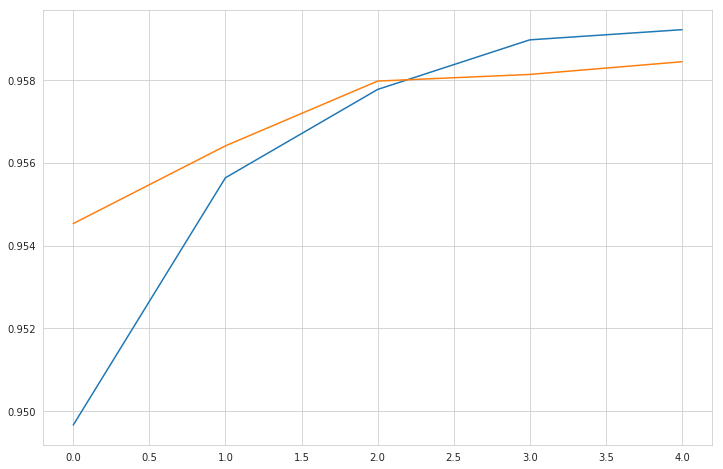

In [81]:
 plt.figure(figsize=(12,8))
 plt.plot(history.history['acc'], label='Train Accuracy')
 plt.plot(history.history['val_acc'], label='Test Accuracy')
 plt.show()

In [82]:
# history = model_treated.fit(X_t_train, y_train, batch_size=batch_size, epochs=epochs, 
                            #validation_data=[X_t_val, y_val], callbacks=[checkpoints_treated, reduce_lr_treated])

In [83]:
# plt.figure(figsize=(12,8))
# plt.plot(history.history['acc'], label='Train Accuracy')
# plt.plot(history.history['val_acc'], label='Test Accuracy')
# plt.show()

In [84]:
 model.load_weights('weights.hdf5')
# model_treated.load_weights('treated_weights.hdf5')

In [85]:
# model2 = Sequential([
#     Embedding(len_voc, 300, input_length=max_len,dropout=0.2,weights=[embedding]),
#     #BatchNormalization(),
#     #Dropout(0.5),
#     Bidirectional(LSTM(300,activation='relu',recurrent_dropout=0.2,consume_less='gpu')),
#     #BatchNormalization(),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')])
# model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model2.summary()

In [86]:
type(y_train)

list

In [87]:
# history = model2.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, 
#                     validation_data=[X_val, y_val], callbacks=[checkpoints2, reduce_lr])

## Results
### Predictions

In [88]:
 pred_val = model.predict(X_val, batch_size=512, verbose=1)
# pred_t_val = model_treated.predict(X_t_val, batch_size=512, verbose=1)

130613/130613 [==============================] - 12s 92us/step


In [89]:
pred_test= model.predict(X_test, batch_size=512, verbose=1)

375806/375806 [==============================] - 34s 89us/step


In [90]:
pred_test[0:20]

array([[0.01352679],
       [0.03232427],
       [0.00303556],
       [0.00906892],
       [0.01083445],
       [0.00121246],
       [0.00271945],
       [0.00553741],
       [0.11637043],
       [0.00125831],
       [0.00037787],
       [0.00168326],
       [0.08297962],
       [0.07217337],
       [0.37286314],
       [0.00081716],
       [0.01822602],
       [0.01140925],
       [0.00425572],
       [0.00073996]], dtype=float32)

In [91]:
# pred_test2[0:10]

#### F1 Scores

In [92]:
 from sklearn.metrics import f1_score

In [93]:
def tweak_threshold(pred, truth):
    thresholds = []
    scores = []
    for thresh in np.arange(0.1, 0.501, 0.01):
        thresh = np.round(thresh, 2)
        thresholds.append(thresh)
        score = f1_score(truth, (pred>thresh).astype(int))
        scores.append(score)
        return np.max(scores), thresholds[np.argmax(scores)]

In [94]:
score_val, threshold_val = tweak_threshold(pred_val, y_val)

print(f"Scored {round(score_val, 4)} for threshold {threshold_val} with treated texts on validation data")

Scored 0.5616 for threshold 0.1 with treated texts on validation data


In [95]:
pred_val[0:10]

array([[0.03526527],
       [0.00954842],
       [0.00034888],
       [0.00149784],
       [0.00124095],
       [0.01304219],
       [0.00046427],
       [0.000531  ],
       [0.09860393],
       [0.00071293]], dtype=float32)

In [96]:
y_val[0:10]

[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [97]:
submission = test[['qid']].copy()
submission['prediction'] = (pred_test > 0.6).astype(int)


In [98]:
submission.to_csv('submission.csv', index=False)

In [99]:
!head submission.csv


qid,prediction
0000163e3ea7c7a74cd7,0
00002bd4fb5d505b9161,0
00007756b4a147d2b0b3,0
000086e4b7e1c7146103,0
0000c4c3fbe8785a3090,0
000101884c19f3515c1a,0
00010f62537781f44a47,0
00012afbd27452239059,0
00014894849d00ba98a9,0
